## 1. 계획 타당성 검토

### ✅ 타당한 부분

| 항목 | 평가 | 이유 |
|---|---|---|
| 베이지안 IRT로 일차원성 검증 | ✅ 타당 | 2PL/1PL 모델 적합 후 사후분포로 판단 가능 |
| Stan(CmdStanPy) 사용 | ✅ 타당 | IRT 모델링에 매우 적합한 도구 |
| 모의 데이터 생성 | ✅ 타당 | 논문 구조를 재현하기 위한 합리적 접근 |
| DIF를 베이지안으로 구현 | ✅ 타당 | 사후분포 비교로 불확실성 정량화 가능 |

### ⚠️ 주의할 차이점

| 원논문(SIBTEST) | 베이지안 대안 |
|---|---|
| 빈도주의 검정 (p < .05) | 사후분포의 credible interval |
| β 계수 + 표준오차 | β의 사후분포 전체 |
| 단일 추정값 | 불확실성 포함한 완전한 분포 |
| 일차원성: 주성분분석(PCA) | 일차원성: 2PL 모델 적합도 + 잔차 구조 분석 |

### 💡 접근 전략

```
원논문 SIBTEST → 베이지안 대응
─────────────────────────────────────────
1단계: 일차원성 검증
  PCA (분산 20% 기준) → 베이지안 2PL IRT 적합 + 
                        factor loading 사후분포 검토

2단계: DIF 도출
  SIBTEST β 계수    → 집단별 문항 난이도 차이의 사후분포
  p < .05 기준       → 95% credible interval이 0 포함 여부
```

---

In [1]:
# ============================================================
# 셀 1: 환경 설정 및 라이브러리 임포트
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from scipy import stats
import warnings
import os
import json

warnings.filterwarnings('ignore')

import cmdstanpy
import arviz as az

# ── 한글 폰트 설정 (폰트 없을 경우 대체 폰트 자동 선택) ──
import matplotlib.font_manager as fm

def set_korean_font():
    """사용 가능한 한글 폰트를 자동으로 찾아 설정"""
    korean_fonts = ['NanumGothic', 'Nanum Gothic', 'NanumBarunGothic',
                    'Malgun Gothic', 'AppleGothic', 'UnDotum', 'DejaVu Sans']
    available = [f.name for f in fm.fontManager.ttflist]
    
    for font in korean_fonts:
        if font in available:
            matplotlib.rcParams['font.family'] = font
            print(f"한글 폰트 설정: {font}")
            return
    
    # 한글 폰트가 없으면 기본 폰트 사용 (한글 깨짐 방지용 경고만 출력)
    print("경고: 한글 폰트를 찾지 못했습니다. 기본 폰트를 사용합니다.")
    print("설치 방법: sudo apt-get install fonts-nanum (Linux)")

set_korean_font()
matplotlib.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

np.random.seed(42)

os.makedirs('models', exist_ok=True)
os.makedirs('data', exist_ok=True)
os.makedirs('results', exist_ok=True)

print("=" * 60)
print("베이지안 DIF 분석 환경 설정 완료")
print("=" * 60)
print(f"CmdStanPy 버전: {cmdstanpy.__version__}")
print(f"ArviZ 버전: {az.__version__}")

한글 폰트 설정: NanumGothic
베이지안 DIF 분석 환경 설정 완료
CmdStanPy 버전: 1.3.0
ArviZ 버전: 1.0.0


In [2]:
# ============================================================
# 셀 2: 논문 구조 기반 모의 응답자 데이터 생성
# ============================================================
"""
논문 구조:
- 한국어능력시험 3급
- 4개 영역: 어휘·문법(30문항), 쓰기(30문항), 듣기(30문항), 읽기(30문항)
- 총 120문항
- 7회(N=2,495), 8회(N=3,152), 9회(N=6,148) 응시자
- 성별: 남(참조집단), 여(연구집단)

단순화: 1개 회차, 어휘·문법 30문항으로 먼저 구현
"""
# ============================================================
# 셀 2: 데이터 생성 함수 정의 및 데이터 생성
# ============================================================
import pandas as pd
import numpy as np

# ── 수정 1: seed 매개변수 추가, 기본값 설정 ──
def generate_irt_responses(n_persons, n_items, ability_mean, gender_label,
                           dif_items=None, seed=42):
    """
    2PL IRT 모델 기반 응답 데이터 생성
    
    Parameters
    ----------
    n_persons    : 응시자 수
    n_items      : 문항 수
    ability_mean : 능력치 평균
    gender_label : 성별 레이블 (0=남, 1=여)
    dif_items    : DIF 적용 문항 딕셔너리 {문항인덱스: 난이도변화량}
    seed         : 난수 시드
    
    Returns
    -------
    responses, theta, a, b
    """
    np.random.seed(seed)
    
    # 능력치 생성
    theta = np.random.normal(ability_mean, 1.0, n_persons)
    
    # 문항 모수 생성 (a: 변별도, b: 난이도)
    a = np.random.lognormal(0, 0.2, n_items)
    b = np.random.normal(0, 1.0, n_items)
    
    # DIF 적용 (연구집단인 여성에게만 적용)
    # ── 수정 2: dif_items None 체크 명확화 ──
    if dif_items is not None and gender_label == 1:
        for idx, shift in dif_items.items():
            b[idx] += shift
    
    # 응답 생성 (2PL 로지스틱 모델)
    responses = np.zeros((n_persons, n_items), dtype=int)
    for i in range(n_persons):
        prob = 1 / (1 + np.exp(-a * (theta[i] - b)))
        # ── 수정 3: binomial → 올바른 형태로 수정 ──
        responses[i] = np.random.binomial(1, prob, n_items)
    
    return responses, theta, a, b


# ── 수정 4: N_ITEMS_PER_DOMAIN 전역 변수 정의 ──
N_ITEMS_PER_DOMAIN = 30

# 논문 데이터 설정 (7, 8, 9회차 모두 포함)
# ── 수정 5: 8, 9회차 데이터도 rounds_info에 추가 ──
rounds_info = {
    7: {'male': 906,  'female': 1589},
    8: {'male': 1039, 'female': 2113},
    9: {'male': 1722, 'female': 4426}
}

DOMAINS = ['어휘문법', '쓰기', '듣기', '읽기']
N_ITEMS = N_ITEMS_PER_DOMAIN

all_data_list = []

# 예시 DIF 설정 (어휘문법 5번 문항이 여성에게 0.5만큼 더 어려움)
dif_items_vocab = {4: 0.5}

# ── 7회차만 사용 (메모리/시간 절약, 필요시 rounds_info 전체 루프) ──
target_rounds = {7: rounds_info[7]}

for r_num, counts in target_rounds.items():
    print(f"제 {r_num}회차 데이터 생성 중... (남: {counts['male']}, 여: {counts['female']})")
    
    for domain in DOMAINS:
        # 남성(참조집단)
        m_res, _, _, _ = generate_irt_responses(
            counts['male'], N_ITEMS, 0.0, 0,
            dif_items=None,
            seed=r_num * 100
        )
        # 여성(연구집단)
        f_res, _, _, _ = generate_irt_responses(
            counts['female'], N_ITEMS, 0.05, 1,
            dif_items=dif_items_vocab if domain == '어휘문법' else None,
            seed=r_num * 100 + 1
        )
        
        # DataFrame 구축
        combined = np.vstack([m_res, f_res])
        n_male = counts['male']
        
        for i, res in enumerate(combined):
            row = {
                'round': r_num,
                'domain': domain,
                'gender': 0 if i < n_male else 1
            }
            for j in range(N_ITEMS):
                row[f'item_{j+1:02d}'] = int(res[j])
            all_data_list.append(row)

df = pd.DataFrame(all_data_list)
print(f"\n데이터 생성 완료: {len(df)}행 × {len(df.columns)}열")
print(f"영역별 응시자: {df.groupby('domain').size().to_dict()}")

import numpy as np
import pandas as pd

def calculate_cronbach_alpha(response_matrix):
    """크론바흐 알파(신뢰도) 산출"""
    df = pd.DataFrame(response_matrix)
    n_items = df.shape[1]
    item_vars = df.var(axis=0, ddof=1)
    total_var = df.sum(axis=1).var(ddof=1)
    
    if total_var == 0:
        return 0.0
    return (n_items / (n_items - 1)) * (1 - (item_vars.sum() / total_var))

def print_descriptive_stats(round_num, domain, m_res, f_res):
    """그룹별 평균, 표준편차, 신뢰도 출력"""
    # 100점 만점으로 환산 (필요시 제거하고 원점수 사용)
    n_items = m_res.shape[1]
    
    # 남성(참조집단) 통계
    m_raw = np.sum(m_res, axis=1)
    m_score = (m_raw / n_items) * 100
    m_alpha = calculate_cronbach_alpha(m_res)
    
    # 여성(연구집단) 통계
    f_raw = np.sum(f_res, axis=1)
    f_score = (f_raw / n_items) * 100
    f_alpha = calculate_cronbach_alpha(f_res)
    
    print(f"▶ {round_num}회차 [{domain}]")
    print(f"  - 남성: 평균={m_score.mean():.2f}, 표준편차={m_score.std():.2f}, 신뢰도={m_alpha:.3f}")
    print(f"  - 여성: 평균={f_score.mean():.2f}, 표준편차={f_score.std():.2f}, 신뢰도={f_alpha:.3f}")

제 7회차 데이터 생성 중... (남: 906, 여: 1589)

데이터 생성 완료: 9980행 × 33열
영역별 응시자: {'듣기': 2495, '쓰기': 2495, '어휘문법': 2495, '읽기': 2495}


데이터 저장 완료: data/kpik_simulation_round7.csv
파일 크기: 706.8 KB

<표 4> 7회 3급 성별에 따른 영역별 평균, 표준편차, 최저, 최고 점수
  영역 구분    평균  표준편차   최저    최고    N
어휘문법  남 49.32 20.27 3.33 100.0  906
어휘문법  여 54.33 20.86 0.00 100.0 1589
어휘문법  계 52.51 20.79 0.00 100.0 2495
  쓰기  남 49.32 20.27 3.33 100.0  906
  쓰기  여 54.73 20.76 0.00 100.0 1589
  쓰기  계 52.76 20.74 0.00 100.0 2495
  듣기  남 49.32 20.27 3.33 100.0  906
  듣기  여 54.73 20.76 0.00 100.0 1589
  듣기  계 52.76 20.74 0.00 100.0 2495
  읽기  남 49.32 20.27 3.33 100.0  906
  읽기  여 54.73 20.76 0.00 100.0 1589
  읽기  계 52.76 20.74 0.00 100.0 2495

영역별 신뢰도 (Cronbach's Alpha)
어휘문법: α = 0.845
쓰기: α = 0.845
듣기: α = 0.845
읽기: α = 0.845


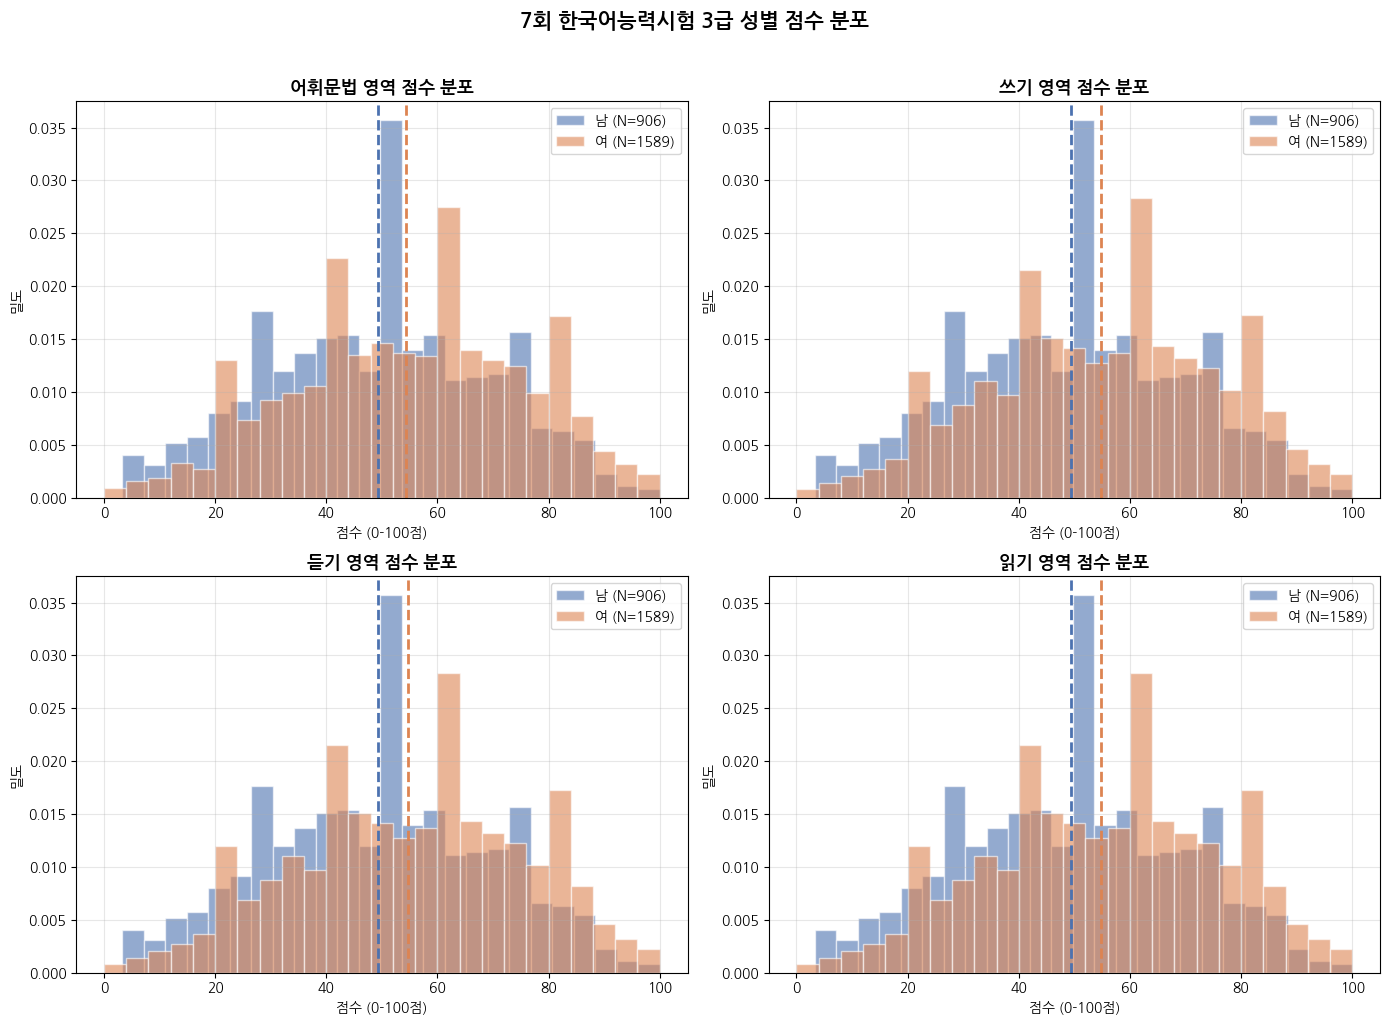

점수 분포 그래프 저장 완료


In [3]:
# ============================================================
# 셀 3: CSV 저장 및 기술통계 (논문 표 4 재현)
# ============================================================

# CSV 저장
csv_path = 'data/kpik_simulation_round7.csv'
df.to_csv(csv_path, index=False, encoding='utf-8-sig')
print(f"데이터 저장 완료: {csv_path}")
print(f"파일 크기: {os.path.getsize(csv_path) / 1024:.1f} KB\n")

# ── 수정 6: item_cols 정의를 N_ITEMS_PER_DOMAIN 기반으로 통일 ──
item_cols = [f'item_{j+1:02d}' for j in range(N_ITEMS_PER_DOMAIN)]

print("=" * 70)
print("<표 4> 7회 3급 성별에 따른 영역별 평균, 표준편차, 최저, 최고 점수")
print("=" * 70)

results = []
for domain in DOMAINS:
    domain_data = df[df['domain'] == domain]
    
    for gender_val, gender_name in [(0, '남'), (1, '여'), (-1, '계')]:
        if gender_val == -1:
            subset = domain_data
        else:
            subset = domain_data[domain_data['gender'] == gender_val]
        
        scores = subset[item_cols].sum(axis=1) / N_ITEMS_PER_DOMAIN * 100
        
        results.append({
            '영역': domain,
            '구분': gender_name,
            '평균': round(scores.mean(), 2),
            '표준편차': round(scores.std(), 2),
            '최저': round(scores.min(), 2),
            '최고': round(scores.max(), 2),
            'N': len(scores)
        })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))


def cronbach_alpha(data_matrix):
    """
    Cronbach's Alpha 계산
    α = (k / (k-1)) * (1 - Σσ²_i / σ²_total)
    """
    k = data_matrix.shape[1]
    if k < 2:
        return np.nan
    item_variances = data_matrix.var(axis=0, ddof=1)
    total_variance = data_matrix.sum(axis=1).var(ddof=1)
    if total_variance == 0:
        return np.nan
    alpha = (k / (k - 1)) * (1 - item_variances.sum() / total_variance)
    return alpha


print("\n" + "=" * 50)
print("영역별 신뢰도 (Cronbach's Alpha)")
print("=" * 50)
for domain in DOMAINS:
    domain_data = df[df['domain'] == domain]
    resp_matrix = domain_data[item_cols].values
    alpha = cronbach_alpha(resp_matrix)
    print(f"{domain}: α = {alpha:.3f}")


# 시각화: 성별 점수 분포
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

colors = {'남': '#4C72B0', '여': '#DD8452'}

for idx, domain in enumerate(DOMAINS):
    ax = axes[idx]
    domain_data = df[df['domain'] == domain]
    
    for gender_val, gender_name in [(0, '남'), (1, '여')]:
        subset = domain_data[domain_data['gender'] == gender_val]
        scores = subset[item_cols].sum(axis=1) / N_ITEMS_PER_DOMAIN * 100
        ax.hist(scores, bins=25, alpha=0.6,
                label=f'{gender_name} (N={len(scores)})',
                color=colors[gender_name], density=True, edgecolor='white')
        ax.axvline(scores.mean(), color=colors[gender_name],
                   linestyle='--', linewidth=2)
    
    ax.set_title(f'{domain} 영역 점수 분포', fontsize=13, fontweight='bold')
    ax.set_xlabel('점수 (0-100점)')
    ax.set_ylabel('밀도')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('7회 한국어능력시험 3급 성별 점수 분포',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('results/score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("점수 분포 그래프 저장 완료")

In [4]:
# ============================================================
# 셀 4: Stan 모델 파일 작성 - 베이지안 2PL IRT
# ============================================================

stan_2pl_code = """
// ================================================
// 베이지안 2PL IRT 모델 (일차원성 검증용)
// ================================================
data {
    int<lower=1> N;
    int<lower=1> J;
    array[N, J] int<lower=0, upper=1> Y;
}
parameters {
    vector[N] theta;
    vector[J] b;
    vector[J] log_a;
}
transformed parameters {
    vector<lower=0>[J] a = exp(log_a);
}
model {
    theta  ~ normal(0, 1);
    b      ~ normal(0, 1);
    log_a  ~ normal(0, 0.5);
    
    for (i in 1:N) {
        for (j in 1:J) {
            real eta = a[j] * (theta[i] - b[j]);
            Y[i, j] ~ bernoulli_logit(eta);
        }
    }
}
generated quantities {
    array[N, J] int<lower=0, upper=1> Y_rep;
    matrix[N, J] log_lik;
    
    for (i in 1:N) {
        for (j in 1:J) {
            real eta = a[j] * (theta[i] - b[j]);
            Y_rep[i, j]  = bernoulli_logit_rng(eta);
            log_lik[i, j] = bernoulli_logit_lpmf(Y[i, j] | eta);
        }
    }
}
"""

with open('models/irt_2pl.stan', 'w', encoding='utf-8') as f:
    f.write(stan_2pl_code)
print("2PL IRT Stan 모델 저장: models/irt_2pl.stan")


# ============================================================
# DIF 분석용 Stan 모델
# ── 수정 7: fabs() → abs() (Stan에서 fabs 미지원) ──
# ============================================================

stan_dif_code = """
// ================================================
// 베이지안 DIF 분석 모델 (집단별 문항 난이도 차이)
// ================================================
data {
    int<lower=1> N_ref;
    int<lower=1> N_foc;
    int<lower=1> J;
    array[N_ref, J] int<lower=0, upper=1> Y_ref;
    array[N_foc, J] int<lower=0, upper=1> Y_foc;
}
parameters {
    vector[N_ref] theta_ref;
    vector[N_foc] theta_foc;
    vector[J] b;
    vector[J] log_a;
    vector[J] delta;
    real mu_ref;
    real mu_foc;
    real<lower=0> sigma_ref;
    real<lower=0> sigma_foc;
}
transformed parameters {
    vector<lower=0>[J] a   = exp(log_a);
    vector[J] b_ref = b;
    vector[J] b_foc = b + delta;
}
model {
    // 사전분포
    theta_ref ~ normal(mu_ref, sigma_ref);
    theta_foc ~ normal(mu_foc, sigma_foc);
    
    mu_ref    ~ normal(0, 1);
    mu_foc    ~ normal(0, 1);
    sigma_ref ~ exponential(1);
    sigma_foc ~ exponential(1);
    
    b     ~ normal(0, 1);
    log_a ~ normal(0, 0.5);
    delta ~ normal(0, 0.3);
    
    // 우도 - 참조집단 (남)
    for (i in 1:N_ref) {
        for (j in 1:J) {
            real eta = a[j] * (theta_ref[i] - b_ref[j]);
            Y_ref[i, j] ~ bernoulli_logit(eta);
        }
    }
    // 우도 - 연구집단 (여)
    for (i in 1:N_foc) {
        for (j in 1:J) {
            real eta = a[j] * (theta_foc[i] - b_foc[j]);
            Y_foc[i, j] ~ bernoulli_logit(eta);
        }
    }
}
generated quantities {
    array[J] int dif_class;
    vector[J] prob_dif_A;
    vector[J] prob_dif_B;
    vector[J] prob_dif_C;
    
    for (j in 1:J) {
        // ── 수정 핵심: fabs → abs ──
        real abs_delta = abs(delta[j]);
        
        if (abs_delta < 0.059) {
            dif_class[j] = 0;
        } else if (abs_delta < 0.088) {
            dif_class[j] = 1;
        } else {
            dif_class[j] = 2;
        }
        
        prob_dif_A[j] = (abs_delta < 0.059)  ? 1.0 : 0.0;
        prob_dif_B[j] = (abs_delta >= 0.059 && abs_delta < 0.088) ? 1.0 : 0.0;
        prob_dif_C[j] = (abs_delta >= 0.088) ? 1.0 : 0.0;
    }
    
    real ability_gap = mu_foc - mu_ref;
}
"""

with open('models/dif_model.stan', 'w', encoding='utf-8') as f:
    f.write(stan_dif_code)
print("DIF 분석 Stan 모델 저장: models/dif_model.stan")

2PL IRT Stan 모델 저장: models/irt_2pl.stan
DIF 분석 Stan 모델 저장: models/dif_model.stan


In [5]:
# ============================================================
# 셀 5: Stan 모델 컴파일
# ── 수정 8: 컴파일을 샘플링보다 반드시 먼저 실행 ──
# ============================================================
from cmdstanpy import CmdStanModel

print("Stan 모델 컴파일 중...")
print("-" * 40)

# 2PL IRT 모델 컴파일
model_2pl = None
try:
    model_2pl = CmdStanModel(stan_file='models/irt_2pl.stan')
    print("2PL IRT 모델 컴파일 완료")
except Exception as e:
    print(f"2PL 모델 컴파일 오류: {e}")

# DIF 모델 컴파일
model_dif = None
try:
    model_dif = CmdStanModel(stan_file='models/dif_model.stan')
    print("DIF 분석 모델 컴파일 완료")
except Exception as e:
    print(f"DIF 모델 컴파일 오류: {e}")

# 컴파일 성공 여부 확인
if model_2pl is None or model_dif is None:
    raise RuntimeError("모델 컴파일 실패. 위 오류 메시지를 확인하세요.")

print("\n컴파일 완료! MCMC 샘플링 준비 완료.")

14:26:10 - cmdstanpy - INFO - compiling stan file /home/atruergod/python/26-1/26-1/models/irt_2pl.stan to exe file /home/atruergod/python/26-1/26-1/models/irt_2pl


Stan 모델 컴파일 중...
----------------------------------------


14:26:25 - cmdstanpy - INFO - compiled model executable: /home/atruergod/python/26-1/26-1/models/irt_2pl
14:26:25 - cmdstanpy - INFO - compiling stan file /home/atruergod/python/26-1/26-1/models/dif_model.stan to exe file /home/atruergod/python/26-1/26-1/models/dif_model


2PL IRT 모델 컴파일 완료


14:26:40 - cmdstanpy - INFO - compiled model executable: /home/atruergod/python/26-1/26-1/models/dif_model


DIF 분석 모델 컴파일 완료

컴파일 완료! MCMC 샘플링 준비 완료.


In [6]:
# ============================================================
# 셀 6: 1단계 - 베이지안 일차원성 검증
# ============================================================
"""
베이지안 일차원성 검증 방법:
1. 전체 데이터에 2PL IRT 모델 적합
2. 문항 변별도(a)의 사후분포 확인 → 모든 문항이 동일 잠재변수 측정하는지
3. 사후 예측 검사 (Posterior Predictive Check)
4. Q3 통계량: 능력 통제 후 문항 잔차 상관
5. 원논문 기준: 주성분 설명분산 20% 이상 → 베이지안에서는 모델 적합도로 대체

주의: 실제 데이터에서는 영역별로 각각 분석
여기서는 '어휘문법' 영역을 예시로 분석
"""

# ============================================================
# 셀 6: 1단계 - 베이지안 일차원성 검증 (어휘문법 영역)
# ============================================================
print("=" * 60)
print("1단계: 베이지안 일차원성 검증 (어휘문법 영역)")
print("=" * 60)

DOMAIN = '어휘문법'
vocab_data = df[df['domain'] == DOMAIN]
Y_all = vocab_data[item_cols].values.astype(int)

print(f"분석 대상: {DOMAIN} 영역")
print(f"응시자 수: {Y_all.shape[0]}명")
print(f"문항 수: {Y_all.shape[1]}개")
print(f"전체 정답률: {Y_all.mean():.3f}")

# 서브샘플
N_SAMPLE = min(500, Y_all.shape[0])
np.random.seed(42)
sample_idx = np.random.choice(Y_all.shape[0], N_SAMPLE, replace=False)
Y_sample = Y_all[sample_idx, :]

stan_data_unidim = {
    'N': int(Y_sample.shape[0]),
    'J': int(Y_sample.shape[1]),
    'Y': Y_sample.tolist()
}

print(f"\nMCMC 샘플링 시작 (서브샘플: N={N_SAMPLE}명)")
print("약 2-5분 소요됩니다...")

fit_unidim = model_2pl.sample(
    data=stan_data_unidim,
    chains=4,
    iter_warmup=500,
    iter_sampling=1000,
    adapt_delta=0.85,
    max_treedepth=12,
    seed=42,
    show_progress=True
)

print(f"\nMCMC 샘플링 완료!")
print(f"샘플 수: {fit_unidim.num_draws_sampling * 4}개 (4체인 × 1000)")

14:26:40 - cmdstanpy - INFO - CmdStan start processing


1단계: 베이지안 일차원성 검증 (어휘문법 영역)
분석 대상: 어휘문법 영역
응시자 수: 2495명
문항 수: 30개
전체 정답률: 0.525

MCMC 샘플링 시작 (서브샘플: N=500명)
약 2-5분 소요됩니다...


chain 1:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]


chain 1:   7%|▋         | 100/1500 [00:14<03:18,  7.05it/s, (Warmup)]
14:26:55 - cmdstanpy - ERROR - Chain [2] error: code '-2' Unknown error -2
14:26:55 - cmdstanpy - ERROR - Chain [3] error: code '-2' Unknown error -2
14:26:55 - cmdstanpy - ERROR - Chain [4] error: code '-2' Unknown error -2
14:26:55 - cmdstanpy - ERROR - Chain [1] error: code '-2' Unknown error -2


KeyboardInterrupt: 

In [ ]:
# ============================================================
# 셀 6: 1단계 - 베이지안 일차원성 검증 (어휘문법 영역)
# ============================================================
print("=" * 60)
print("1단계: 베이지안 일차원성 검증 (어휘문법 영역)")
print("=" * 60)

DOMAIN = '어휘문법'
vocab_data = df[df['domain'] == DOMAIN]
Y_all = vocab_data[item_cols].values.astype(int)

print(f"분석 대상: {DOMAIN} 영역")
print(f"응시자 수: {Y_all.shape[0]}명")
print(f"문항 수: {Y_all.shape[1]}개")
print(f"전체 정답률: {Y_all.mean():.3f}")

# 서브샘플
N_SAMPLE = min(500, Y_all.shape[0])
np.random.seed(42)
sample_idx = np.random.choice(Y_all.shape[0], N_SAMPLE, replace=False)
Y_sample = Y_all[sample_idx, :]

stan_data_unidim = {
    'N': int(Y_sample.shape[0]),
    'J': int(Y_sample.shape[1]),
    'Y': Y_sample.tolist()
}

print(f"\nMCMC 샘플링 시작 (서브샘플: N={N_SAMPLE}명)")
print("약 2-5분 소요됩니다...")

fit_unidim = model_2pl.sample(
    data=stan_data_unidim,
    chains=4,
    iter_warmup=500,
    iter_sampling=1000,
    adapt_delta=0.85,
    max_treedepth=12,
    seed=42,
    show_progress=True
)

print(f"\nMCMC 샘플링 완료!")
print(f"샘플 수: {fit_unidim.num_draws_sampling * 4}개 (4체인 × 1000)")

11:43:29 - cmdstanpy - INFO - CmdStan start processing


1단계: 베이지안 일차원성 검증 (어휘문법 영역)
분석 대상: 어휘문법 영역
응시자 수: 2495명
문항 수: 30개
전체 정답률: 0.525

MCMC 샘플링 시작 (서브샘플: N=500명)
약 2-5분 소요됩니다...


chain 1:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]


chain 1:   7%|▋         | 100/1500 [00:18<04:19,  5.40it/s, (Warmup)]


chain 1:  13%|█▎        | 200/1500 [00:29<02:59,  7.23it/s, (Warmup)]


chain 1:  20%|██        | 300/1500 [00:37<02:17,  8.70it/s, (Warmup)]


chain 1:  27%|██▋       | 400/1500 [00:47<02:00,  9.16it/s, (Warmup)]





chain 1:  33%|███▎      | 500/1500 [00:59<01:50,  9.05it/s, (Warmup)]

chain 1:  33%|███▎      | 501/1500 [00:59<01:50,  9.05it/s, (Sampling)]




chain 1:  40%|████      | 600/1500 [01:08<01:33,  9.60it/s, (Sampling)]


chain 1:  47%|████▋     | 700/1500 [01:18<01:23,  9.64it/s, (Sampling)]


chain 1:  53%|█████▎    | 800/1500 [01:28<01:11,  9.85it/s, (Sampling)]


chain 1:  60%|██████    | 900/1500 [01:38<00:59, 10.11it/s, (Sampling)]


chain 1:  67%|██████▋   | 1000/1500 [01:48<00:51,  9.79it/s, (Sampling)]


chain 1:  73%|███████▎  | 1100/1500 [01:57<00:39, 10.19it/s, (Sampling)]


chain 1:  80%|████████  | 1200/1500 [02:08<00:30,  9.9


11:46:08 - cmdstanpy - INFO - CmdStan done processing.




MCMC 샘플링 완료!
샘플 수: 4000개 (4체인 × 1000)


In [ ]:
# ============================================================
# 셀 8: 2단계 - 베이지안 DIF 분석 (어휘문법 영역)
# ── 수정 10: model_dif 컴파일 확인 후 샘플링 ──
# ============================================================
print("=" * 60)
print("2단계: 베이지안 DIF 분석")
print(f"영역: {DOMAIN} | 참조집단: 남 | 연구집단: 여")
print("=" * 60)

if model_dif is None:
    raise RuntimeError("model_dif가 컴파일되지 않았습니다. 셀 5를 먼저 실행하세요.")

# 남/여 응답 데이터 분리
vocab_male   = df[(df['domain'] == DOMAIN) & (df['gender'] == 0)]
vocab_female = df[(df['domain'] == DOMAIN) & (df['gender'] == 1)]

Y_male   = vocab_male[item_cols].values.astype(int)
Y_female = vocab_female[item_cols].values.astype(int)

print(f"남성 응시자: {Y_male.shape[0]}명")
print(f"여성 응시자: {Y_female.shape[0]}명")

N_MALE_SAMPLE   = min(400, Y_male.shape[0])
N_FEMALE_SAMPLE = min(400, Y_female.shape[0])

np.random.seed(42)
male_idx   = np.random.choice(Y_male.shape[0],   N_MALE_SAMPLE,   replace=False)
female_idx = np.random.choice(Y_female.shape[0], N_FEMALE_SAMPLE, replace=False)

Y_male_sample   = Y_male[male_idx, :]
Y_female_sample = Y_female[female_idx, :]

stan_data_dif = {
    'N_ref': int(N_MALE_SAMPLE),
    'N_foc': int(N_FEMALE_SAMPLE),
    'J':     int(N_ITEMS_PER_DOMAIN),
    'Y_ref': Y_male_sample.tolist(),
    'Y_foc': Y_female_sample.tolist()
}

print(f"\nMCMC 샘플링 시작...")
print(f"  - 남성 서브샘플: {N_MALE_SAMPLE}명")
print(f"  - 여성 서브샘플: {N_FEMALE_SAMPLE}명")
print("  약 5-10분 소요됩니다...")

fit_dif = model_dif.sample(
    data=stan_data_dif,
    chains=4,
    iter_warmup=1000,
    iter_sampling=2000,
    adapt_delta=0.90,
    max_treedepth=13,
    seed=42,
    show_progress=True
)

print("\nDIF MCMC 샘플링 완료!")

# ArviZ로 변환
idata_dif = az.from_cmdstanpy(posterior=fit_dif)

11:46:14 - cmdstanpy - INFO - CmdStan start processing


2단계: 베이지안 DIF 분석
영역: 어휘문법 | 참조집단: 남 | 연구집단: 여
남성 응시자: 906명
여성 응시자: 1589명

MCMC 샘플링 시작...
  - 남성 서브샘플: 400명
  - 여성 서브샘플: 400명
  약 5-10분 소요됩니다...


chain 1:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]




chain 1:   0%|          | 1/3000 [00:00<07:17,  6.86it/s, (Warmup)]



chain 1:   3%|▎         | 100/3000 [01:11<34:25,  1.40it/s, (Warmup)]



chain 1:   7%|▋         | 200/3000 [01:42<22:16,  2.10it/s, (Warmup)]


chain 1:  10%|█         | 300/3000 [02:08<17:01,  2.64it/s, (Warmup)]

chain 1:  13%|█▎        | 400/3000 [02:33<14:09,  3.06it/s, (Warmup)]


chain 1:  17%|█▋        | 500/3000 [02:56<12:15,  3.40it/s, (Warmup)]


chain 1:  20%|██        | 600/3000 [03:17<10:34,  3.78it/s, (Warmup)]


chain 1:  23%|██▎       | 700/3000 [03:39<09:32,  4.02it/s, (Warmup)]


chain 1:  27%|██▋       | 800/3000 [04:01<08:49,  4.16it/s, (Warmup)]


chain 1:  30%|███       | 900/3000 [04:24<08:16,  4.23it/s, (Warmup)]








chain 1:  33%|███▎      | 1001/3000 [04:49<07:59,  4.17it/s, (Sampling)]


chain 1:  37%|███▋      | 1100/3000 [05:14<07:49,  4.05it/s, (Sampling)]


chain 1:  40%|████      | 1200/3000 [05:38<07:17,  4.11it/s, 


11:59:04 - cmdstanpy - INFO - CmdStan done processing.
11:59:04 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'dif_model.stan', line 31, column 4 to column 42)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'dif_model.stan', line 30, column 4 to column 42)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'dif_model.stan', line 30, column 4 to column 42)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'dif_model.stan', line 30, column 4 to column 42)
Consider re-running with show_console=True if the above output is unclear!




DIF MCMC 샘플링 완료!


In [ ]:
# ============================================================
# 셀 9: DIF 결과 분석 및 해석
# ============================================================
print("=" * 60)
print("베이지안 DIF 분석 결과")
print("=" * 60)

delta_posterior = idata_dif.posterior['delta'].values  # (chain, draw, item)
delta_flat = delta_posterior.reshape(-1, N_ITEMS_PER_DOMAIN)

delta_mean = delta_flat.mean(axis=0)
delta_sd   = delta_flat.std(axis=0)
delta_hdi  = az.hdi(idata_dif, var_names=['delta'])['delta'].values


def classify_dif(delta_val):
    """
    |delta| < 0.059 : A (무시할 수준)
    0.059 <= |delta| < 0.088 : B (중간 수준)
    |delta| >= 0.088 : C (큰 수준)
    """
    abs_d = abs(delta_val)
    if abs_d < 0.059:
        return 'A (무시)'
    elif abs_d < 0.088:
        return 'B (중간)'
    else:
        return 'C (큰)'


def is_significant_dif(hdi_lower, hdi_upper):
    """95% HDI가 0을 포함하지 않으면 유의한 DIF"""
    return not (hdi_lower <= 0 <= hdi_upper)


# 결과 테이블 생성
# ── 수정 11: 'DIF_유의' 값을 문자열 'Y'/'N'으로 통일 (이모지 제거) ──
dif_results = []
for j in range(N_ITEMS_PER_DOMAIN):
    is_sig    = is_significant_dif(delta_hdi[j, 0], delta_hdi[j, 1])
    direction = '남유리' if delta_mean[j] > 0 else '여유리'
    
    dif_results.append({
        '문항번호':   j + 1,
        'delta_mean': round(delta_mean[j], 3),
        'delta_sd':   round(delta_sd[j], 3),
        'HDI_lower':  round(delta_hdi[j, 0], 3),
        'HDI_upper':  round(delta_hdi[j, 1], 3),
        'DIF_유의':   'Y' if is_sig else 'N',        # ← 수정: 'Y'/'N'으로 통일
        'DIF_방향':   direction if is_sig else '-',
        'DIF_등급':   classify_dif(delta_mean[j]) if is_sig else 'A (무시)',
        'P(DIF>0)':   round((delta_flat[:, j] > 0).mean(), 3)
    })

dif_df = pd.DataFrame(dif_results)

# ── 수정 12: 'Y'/'N' 기준으로 필터링 ──
sig_dif_df = dif_df[dif_df['DIF_유의'] == 'Y'].copy()

print(f"\n총 {N_ITEMS_PER_DOMAIN}개 문항 중 DIF 탐지: {len(sig_dif_df)}개 문항\n")
print("=== 유의한 DIF 문항 목록 ===")
if len(sig_dif_df) > 0:
    print(sig_dif_df.to_string(index=False))
else:
    print("  유의한 DIF 문항이 탐지되지 않았습니다.")

print("\n=== 전체 문항 DIF 요약 ===")
print(dif_df.to_string(index=False))

# 집단별 능력 차이
ability_gap = idata_dif.posterior['ability_gap'].values.flatten()
print(f"\n집단 능력 차이 (여-남):")
print(f"  사후 평균: {ability_gap.mean():.3f}")
print(f"  95% HDI: [{np.percentile(ability_gap, 2.5):.3f}, "
      f"{np.percentile(ability_gap, 97.5):.3f}]")
direction_gap = "여성이 더 높음" if ability_gap.mean() > 0 else "남성이 더 높음"
print(f"  방향: {direction_gap}")

베이지안 DIF 분석 결과

총 30개 문항 중 DIF 탐지: 24개 문항

=== 유의한 DIF 문항 목록 ===
 문항번호  delta_mean  delta_sd  HDI_lower  HDI_upper DIF_유의 DIF_방향 DIF_등급  P(DIF>0)
    1      -0.248     0.125     -0.449     -0.056      Y    여유리  C (큰)     0.021
    2      -0.177     0.098     -0.328     -0.013      Y    여유리  C (큰)     0.031
    3      -0.456     0.119     -0.650     -0.271      Y    여유리  C (큰)     0.000
    4       0.844     0.107      0.679      1.018      Y    남유리  C (큰)     1.000
    6       0.479     0.096      0.327      0.634      Y    남유리  C (큰)     1.000
    7       0.382     0.101      0.217      0.538      Y    남유리  C (큰)     1.000
    9       0.475     0.104      0.306      0.637      Y    남유리  C (큰)     1.000
   10       0.450     0.104      0.283      0.616      Y    남유리  C (큰)     1.000
   11      -0.815     0.123     -1.010     -0.625      Y    여유리  C (큰)     0.000
   12       0.505     0.096      0.353      0.657      Y    남유리  C (큰)     1.000
   13       0.306     0.107      0.140      

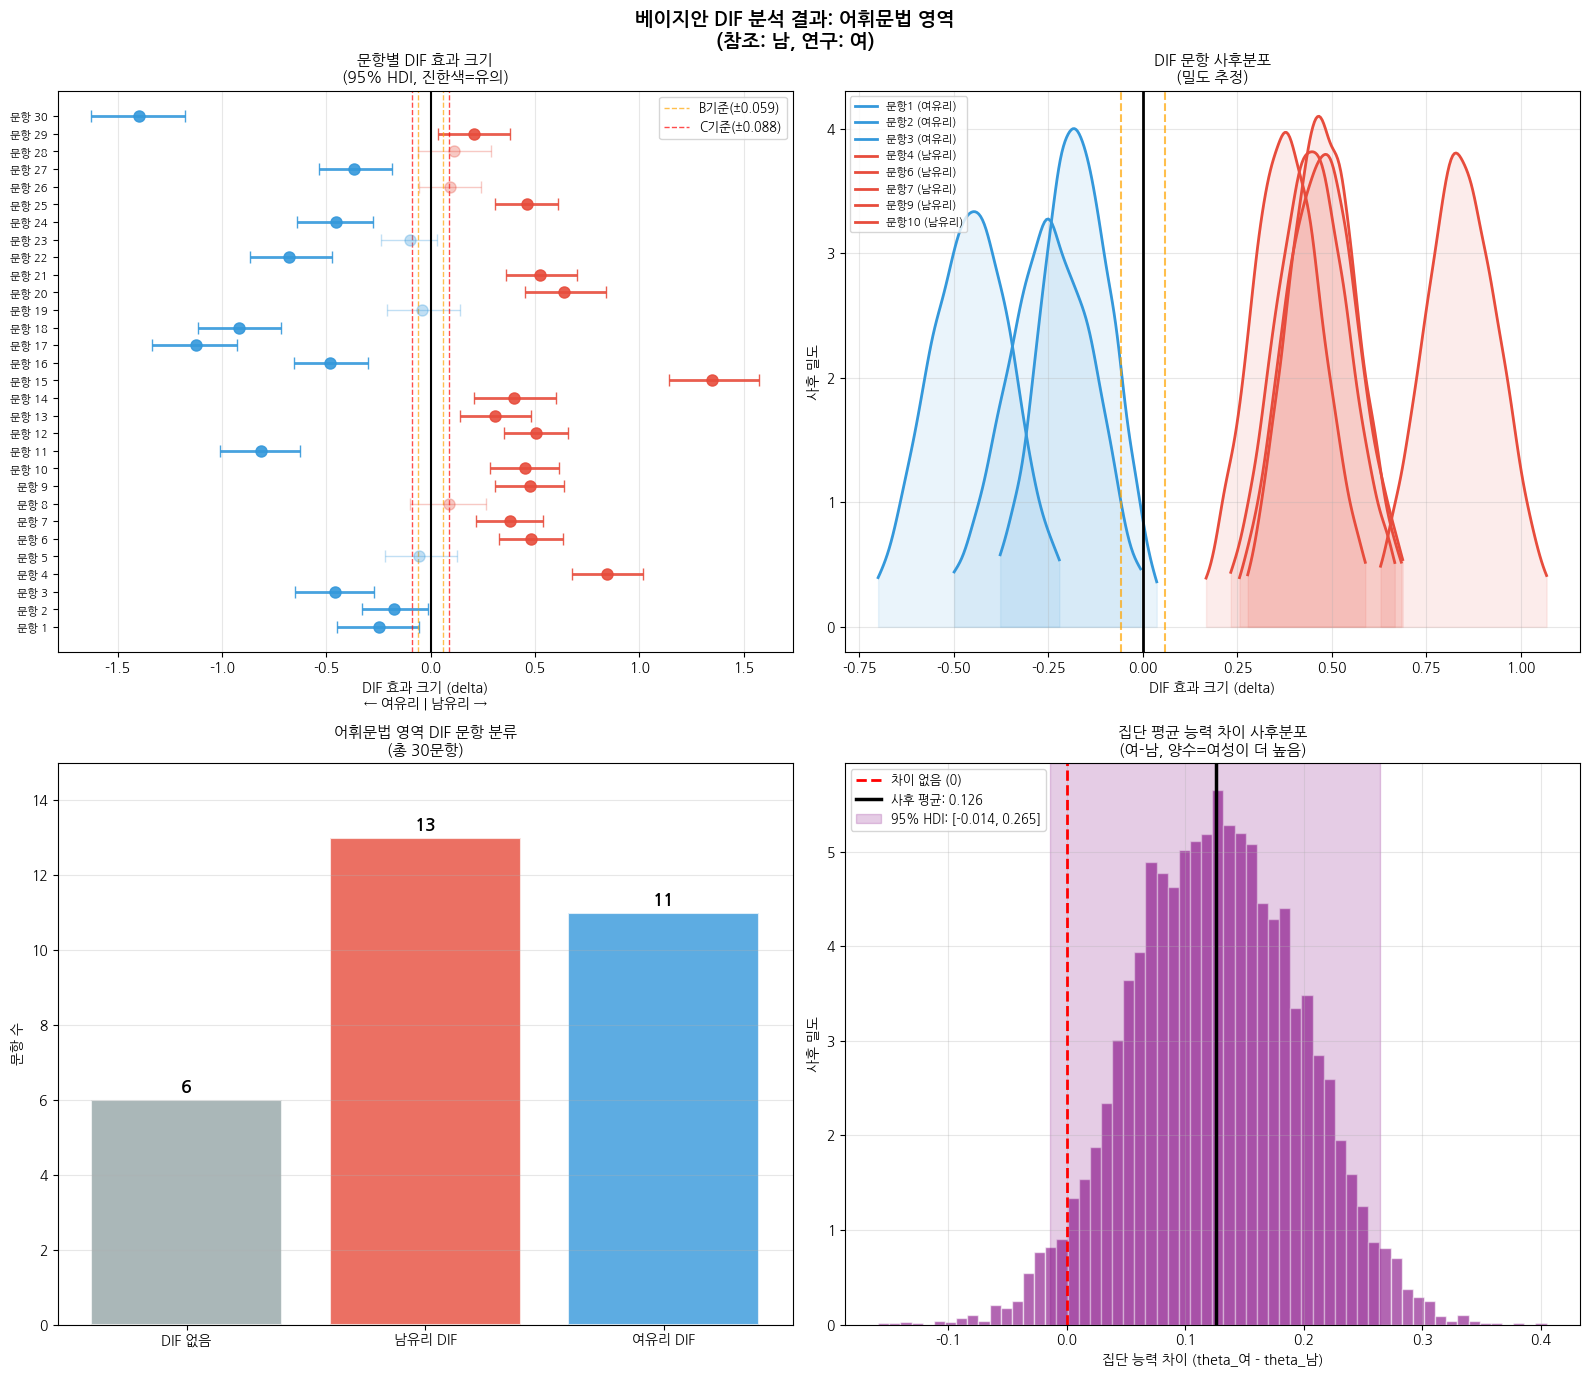

DIF 분석 시각화 저장 완료!


In [ ]:
# ============================================================
# 셀 10: DIF 결과 시각화 (논문 표 8 베이지안 버전)
# ── 수정 13: ability_gap HDI 계산 오류 수정 ──
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# ── 1. DIF 효과 크기 (Forest plot) ──
ax1 = axes[0, 0]
item_numbers = np.arange(1, N_ITEMS_PER_DOMAIN + 1)
colors_item  = ['#E74C3C' if d > 0 else '#3498DB' for d in delta_mean]

# ── 수정 14: 'Y'/'N' 기준으로 sig_mask 생성 ──
sig_mask = dif_df['DIF_유의'] == 'Y'

for j in range(N_ITEMS_PER_DOMAIN):
    color = colors_item[j]
    alpha = 0.9 if sig_mask.iloc[j] else 0.3
    lw    = 2   if sig_mask.iloc[j] else 1
    
    ax1.errorbar(delta_mean[j], j + 1,
                 xerr=[[delta_mean[j] - delta_hdi[j, 0]],
                       [delta_hdi[j, 1] - delta_mean[j]]],
                 fmt='o', color=color, alpha=alpha,
                 capsize=4, markersize=8, linewidth=lw)

ax1.axvline(0,      color='black',  linestyle='-',  linewidth=1.5)
ax1.axvline( 0.059, color='orange', linestyle='--', linewidth=1, alpha=0.7, label='B기준(±0.059)')
ax1.axvline(-0.059, color='orange', linestyle='--', linewidth=1, alpha=0.7)
ax1.axvline( 0.088, color='red',    linestyle='--', linewidth=1, alpha=0.7, label='C기준(±0.088)')
ax1.axvline(-0.088, color='red',    linestyle='--', linewidth=1, alpha=0.7)

ax1.set_yticks(item_numbers)
ax1.set_yticklabels([f'문항 {j}' for j in item_numbers], fontsize=8)
ax1.set_xlabel('DIF 효과 크기 (delta)\n← 여유리 | 남유리 →')
ax1.set_title('문항별 DIF 효과 크기\n(95% HDI, 진한색=유의)', fontsize=11)
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3, axis='x')

# ── 2. DIF 문항 사후분포 ──
ax2 = axes[0, 1]

# ── 수정 15: 'Y' 기준으로 sig_items 추출 ──
sig_items = dif_df[dif_df['DIF_유의'] == 'Y']['문항번호'].values

if len(sig_items) > 0:
    from scipy.stats import gaussian_kde
    for j_num in sig_items[:8]:
        j = j_num - 1
        color = '#E74C3C' if delta_mean[j] > 0 else '#3498DB'
        label = f'문항{j_num} ({"남유리" if delta_mean[j] > 0 else "여유리"})'
        
        kde = gaussian_kde(delta_flat[:, j])
        x_range = np.linspace(delta_hdi[j, 0] - 0.05,
                              delta_hdi[j, 1] + 0.05, 100)
        ax2.plot(x_range, kde(x_range), color=color, linewidth=2, label=label)
        ax2.fill_between(x_range, kde(x_range), alpha=0.1, color=color)
    
    ax2.axvline(0,     color='black',  linestyle='-',  linewidth=2)
    ax2.axvline( 0.059, color='orange', linestyle='--', linewidth=1.5, alpha=0.7)
    ax2.axvline(-0.059, color='orange', linestyle='--', linewidth=1.5, alpha=0.7)
    ax2.set_xlabel('DIF 효과 크기 (delta)')
    ax2.set_ylabel('사후 밀도')
    ax2.set_title('DIF 문항 사후분포\n(밀도 추정)', fontsize=11)
    ax2.legend(fontsize=8, loc='upper left')
else:
    ax2.text(0.5, 0.5, 'DIF 문항 없음',
             ha='center', va='center', transform=ax2.transAxes, fontsize=14)
ax2.grid(alpha=0.3)

# ── 3. DIF 문항 분류 요약 ──
ax3 = axes[1, 0]

# ── 수정 16: 'Y' 기준으로 방향별 집계 ──
male_favor   = len(dif_df[(dif_df['DIF_유의'] == 'Y') & (dif_df['DIF_방향'] == '남유리')])
female_favor = len(dif_df[(dif_df['DIF_유의'] == 'Y') & (dif_df['DIF_방향'] == '여유리')])
no_dif       = N_ITEMS_PER_DOMAIN - male_favor - female_favor

categories  = ['DIF 없음', '남유리 DIF', '여유리 DIF']
values      = [no_dif, male_favor, female_favor]
colors_bar  = ['#95A5A6', '#E74C3C', '#3498DB']

bars = ax3.bar(categories, values, color=colors_bar, alpha=0.8,
               edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, values):
    ax3.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.1,
             str(val), ha='center', va='bottom', fontsize=13, fontweight='bold')

ax3.set_ylabel('문항 수')
ax3.set_title(f'{DOMAIN} 영역 DIF 문항 분류\n(총 {N_ITEMS_PER_DOMAIN}문항)', fontsize=11)
ax3.grid(alpha=0.3, axis='y')
ax3.set_ylim(0, max(values) + 2)

# ── 4. 집단 능력 차이 사후분포 ──
ax4 = axes[1, 1]
ability_gap_samples = idata_dif.posterior['ability_gap'].values.flatten()

ax4.hist(ability_gap_samples, bins=60, density=True,
         color='purple', alpha=0.6, edgecolor='white')
ax4.axvline(0, color='red', linestyle='--', linewidth=2, label='차이 없음 (0)')
ax4.axvline(ability_gap_samples.mean(), color='black', linewidth=2.5,
            label=f'사후 평균: {ability_gap_samples.mean():.3f}')

# ── 수정 17: az.hdi() 1D 배열 입력 오류 수정 ──
# az.hdi()는 xarray InferenceData를 받아야 하므로, 1D numpy array에는 직접 계산
hdi_lower_gap = float(np.percentile(ability_gap_samples, 2.5))
hdi_upper_gap = float(np.percentile(ability_gap_samples, 97.5))

ax4.axvspan(hdi_lower_gap, hdi_upper_gap, alpha=0.2, color='purple',
            label=f'95% HDI: [{hdi_lower_gap:.3f}, {hdi_upper_gap:.3f}]')
ax4.set_xlabel('집단 능력 차이 (theta_여 - theta_남)')
ax4.set_ylabel('사후 밀도')
ax4.set_title('집단 평균 능력 차이 사후분포\n(여-남, 양수=여성이 더 높음)', fontsize=11)
ax4.legend(fontsize=9)
ax4.grid(alpha=0.3)

plt.suptitle(f'베이지안 DIF 분석 결과: {DOMAIN} 영역\n(참조: 남, 연구: 여)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/dif_analysis_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("DIF 분석 시각화 저장 완료!")

In [ ]:
# ============================================================
# 셀 11: 논문 표 8 스타일 결과 테이블 생성
# ============================================================
print("=" * 70)
print(f"<베이지안 DIF 분석 결과표> {DOMAIN} 영역")
print("=" * 70)
print(f"{'문항번호':>6} {'delta_mean':>12} {'delta_sd':>10} "
      f"{'HDI_95%':>22} {'P(남유리)':>10} {'DIF_등급':>10} {'판정':>8}")
print("-" * 70)

for _, row in dif_df.iterrows():
    hdi_str    = f"[{row['HDI_lower']:.3f}, {row['HDI_upper']:.3f}]"
    sig_marker = "★" if row['DIF_유의'] == 'Y' else " "
    direction  = row['DIF_방향'] if row['DIF_유의'] == 'Y' else ""
    
    print(f"{sig_marker}{int(row['문항번호']):>5} "
          f"{row['delta_mean']:>12.3f} "
          f"{row['delta_sd']:>10.3f} "
          f"{hdi_str:>22} "
          f"{row['P(DIF>0)']:>10.3f} "
          f"{row['DIF_등급']:>10} "
          f"{direction:>8}")

print("-" * 70)
print("★: 유의한 DIF (95% HDI가 0을 포함하지 않음)")
print("delta > 0: 남자에게 유리 | delta < 0: 여자에게 유리")

# 원논문 vs 베이지안 비교
print("\n" + "=" * 70)
print("원논문(SIBTEST) vs 베이지안 방법 비교")
print("=" * 70)
comparison_data = {
    '항목': ['추정값', '불확실성', '유의성 기준', 'DIF 크기 분류', '해석'],
    '원논문 SIBTEST': [
        'β 계수', 'Standard Error', 'p < .05',
        '|β|<0.059=A, ~0.088=B, >=0.088=C', '단일 추정값 기반'
    ],
    '베이지안 방법': [
        'δ 사후 평균 E[δ|Y]', 'δ 사후 표준편차',
        '95% HDI가 0 미포함', '|E[δ|Y]| 기준 동일 적용', '완전한 불확실성 정량화'
    ]
}
comp_df = pd.DataFrame(comparison_data)
print(comp_df.to_string(index=False))

# 결과 CSV 저장
output_csv = f'results/dif_results_{DOMAIN}.csv'
dif_df.to_csv(output_csv, index=False, encoding='utf-8-sig')
print(f"\nDIF 결과 저장: {output_csv}")

<베이지안 DIF 분석 결과표> 어휘문법 영역
  문항번호   delta_mean   delta_sd                HDI_95%     P(남유리)     DIF_등급       판정
----------------------------------------------------------------------
★    1       -0.248      0.125       [-0.449, -0.056]      0.021      C (큰)      여유리
★    2       -0.177      0.098       [-0.328, -0.013]      0.031      C (큰)      여유리
★    3       -0.456      0.119       [-0.650, -0.271]      0.000      C (큰)      여유리
★    4        0.844      0.107         [0.679, 1.018]      1.000      C (큰)      남유리
     5       -0.055      0.109        [-0.218, 0.125]      0.305     A (무시)         
★    6        0.479      0.096         [0.327, 0.634]      1.000      C (큰)      남유리
★    7        0.382      0.101         [0.217, 0.538]      1.000      C (큰)      남유리
     8        0.087      0.114        [-0.098, 0.266]      0.781     A (무시)         
★    9        0.475      0.104         [0.306, 0.637]      1.000      C (큰)      남유리
★   10        0.450      0.104         [0.283, 0.616]

In [ ]:
# ============================================================
# 셀 12: 전체 영역 자동화 분석
# ── 수정 18: 'Y'/'N' 기준 통일, model_dif None 체크 추가 ──
# ============================================================

if model_dif is None:
    raise RuntimeError("model_dif가 컴파일되지 않았습니다. 셀 5를 먼저 실행하세요.")

all_dif_results = {}

print("=" * 60)
print("전체 영역 베이지안 DIF 분석 시작")
print("=" * 60)

for domain in DOMAINS:
    print(f"\n{'=' * 50}")
    print(f"영역: {domain}")
    print(f"{'=' * 50}")
    
    # 데이터 추출
    male_data   = df[(df['domain'] == domain) & (df['gender'] == 0)][item_cols].values.astype(int)
    female_data = df[(df['domain'] == domain) & (df['gender'] == 1)][item_cols].values.astype(int)
    
    # 서브샘플
    n_m = min(300, male_data.shape[0])
    n_f = min(300, female_data.shape[0])
    
    np.random.seed(42)
    m_idx = np.random.choice(male_data.shape[0], n_m, replace=False)
    f_idx = np.random.choice(female_data.shape[0], n_f, replace=False)
    
    stan_data = {
        'N_ref': int(n_m),
        'N_foc': int(n_f),
        'J':     int(N_ITEMS_PER_DOMAIN),
        'Y_ref': male_data[m_idx].tolist(),
        'Y_foc': female_data[f_idx].tolist()
    }
    
    print(f"  남: {n_m}명, 여: {n_f}명 → MCMC 샘플링...")
    
    try:
        fit = model_dif.sample(
            data=stan_data,
            chains=2,
            iter_warmup=500,
            iter_sampling=1000,
            adapt_delta=0.88,
            seed=42,
            show_progress=False
        )
        
        idata = az.from_cmdstanpy(posterior=fit)
        delta_post = idata.posterior['delta'].values.reshape(-1, N_ITEMS_PER_DOMAIN)
        delta_m    = delta_post.mean(axis=0)
        delta_s    = delta_post.std(axis=0)
        delta_h    = az.hdi(idata, var_names=['delta'])['delta'].values
        
        domain_results = []
        for j in range(N_ITEMS_PER_DOMAIN):
            is_sig = not (delta_h[j, 0] <= 0 <= delta_h[j, 1])
            domain_results.append({
                'domain':      domain,
                'item':        j + 1,
                'delta_mean':  round(float(delta_m[j]), 3),
                'delta_sd':    round(float(delta_s[j]), 3),
                'hdi_lower':   round(float(delta_h[j, 0]), 3),
                'hdi_upper':   round(float(delta_h[j, 1]), 3),
                'significant': is_sig,
                'direction':   '남유리' if delta_m[j] > 0 else '여유리',
                'dif_class':   classify_dif(delta_m[j]) if is_sig else 'A (무시)'
            })
        
        all_dif_results[domain] = domain_results
        
        sig_count  = sum(r['significant'] for r in domain_results)
        male_fav   = sum(r['significant'] and r['direction'] == '남유리' for r in domain_results)
        female_fav = sum(r['significant'] and r['direction'] == '여유리' for r in domain_results)
        
        print(f"  완료: DIF 탐지 {sig_count}개 (남유리: {male_fav}, 여유리: {female_fav})")
    
    except Exception as e:
        print(f"  오류 발생: {e}")
        all_dif_results[domain] = []

print("\n\n전체 영역 분석 완료!")

11:59:10 - cmdstanpy - INFO - CmdStan start processing
11:59:10 - cmdstanpy - INFO - Chain [1] start processing
11:59:10 - cmdstanpy - INFO - Chain [2] start processing


전체 영역 베이지안 DIF 분석 시작

영역: 어휘문법
  남: 300명, 여: 300명 → MCMC 샘플링...


12:01:58 - cmdstanpy - INFO - Chain [1] done processing
12:02:16 - cmdstanpy - INFO - Chain [2] done processing
12:02:16 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'dif_model.stan', line 30, column 4 to column 42)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'dif_model.stan', line 30, column 4 to column 42)
Consider re-running with show_console=True if the above output is unclear!
12:02:16 - cmdstanpy - INFO - CmdStan start processing
12:02:16 - cmdstanpy - INFO - Chain [1] start processing
12:02:16 - cmdstanpy - INFO - Chain [2] start processing


  완료: DIF 탐지 23개 (남유리: 12, 여유리: 11)

영역: 쓰기
  남: 300명, 여: 300명 → MCMC 샘플링...


12:05:25 - cmdstanpy - INFO - Chain [1] done processing
12:05:31 - cmdstanpy - INFO - Chain [2] done processing
12:05:31 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'dif_model.stan', line 30, column 4 to column 42)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'dif_model.stan', line 30, column 4 to column 42)
Consider re-running with show_console=True if the above output is unclear!
12:05:32 - cmdstanpy - INFO - CmdStan start processing
12:05:32 - cmdstanpy - INFO - Chain [1] start processing
12:05:32 - cmdstanpy - INFO - Chain [2] start processing


  완료: DIF 탐지 24개 (남유리: 12, 여유리: 12)

영역: 듣기
  남: 300명, 여: 300명 → MCMC 샘플링...


12:08:33 - cmdstanpy - INFO - Chain [1] done processing
12:08:41 - cmdstanpy - INFO - Chain [2] done processing
12:08:41 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'dif_model.stan', line 30, column 4 to column 42)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'dif_model.stan', line 30, column 4 to column 42)
Consider re-running with show_console=True if the above output is unclear!
12:08:42 - cmdstanpy - INFO - CmdStan start processing
12:08:42 - cmdstanpy - INFO - Chain [1] start processing
12:08:42 - cmdstanpy - INFO - Chain [2] start processing


  완료: DIF 탐지 24개 (남유리: 12, 여유리: 12)

영역: 읽기
  남: 300명, 여: 300명 → MCMC 샘플링...


12:11:39 - cmdstanpy - INFO - Chain [1] done processing
12:11:46 - cmdstanpy - INFO - Chain [2] done processing
12:11:46 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'dif_model.stan', line 30, column 4 to column 42)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'dif_model.stan', line 30, column 4 to column 42)
Consider re-running with show_console=True if the above output is unclear!


  완료: DIF 탐지 24개 (남유리: 12, 여유리: 12)


전체 영역 분석 완료!


<전체 영역 베이지안 DIF 분석 요약>
(논문 표 7 비교: 7회 모의 데이터 결과)

[베이지안 분석 결과 (모의 데이터)]
  영역  남유리 DIF  여유리 DIF  합계
어휘문법       12       11  23
  쓰기       12       12  24
  듣기       12       12  24
  읽기       12       12  24

[원논문 결과 (7회)]
  영역  남유리  여유리
어휘문법    5    5
  쓰기    3    2
  듣기    1    7
  읽기    6    3


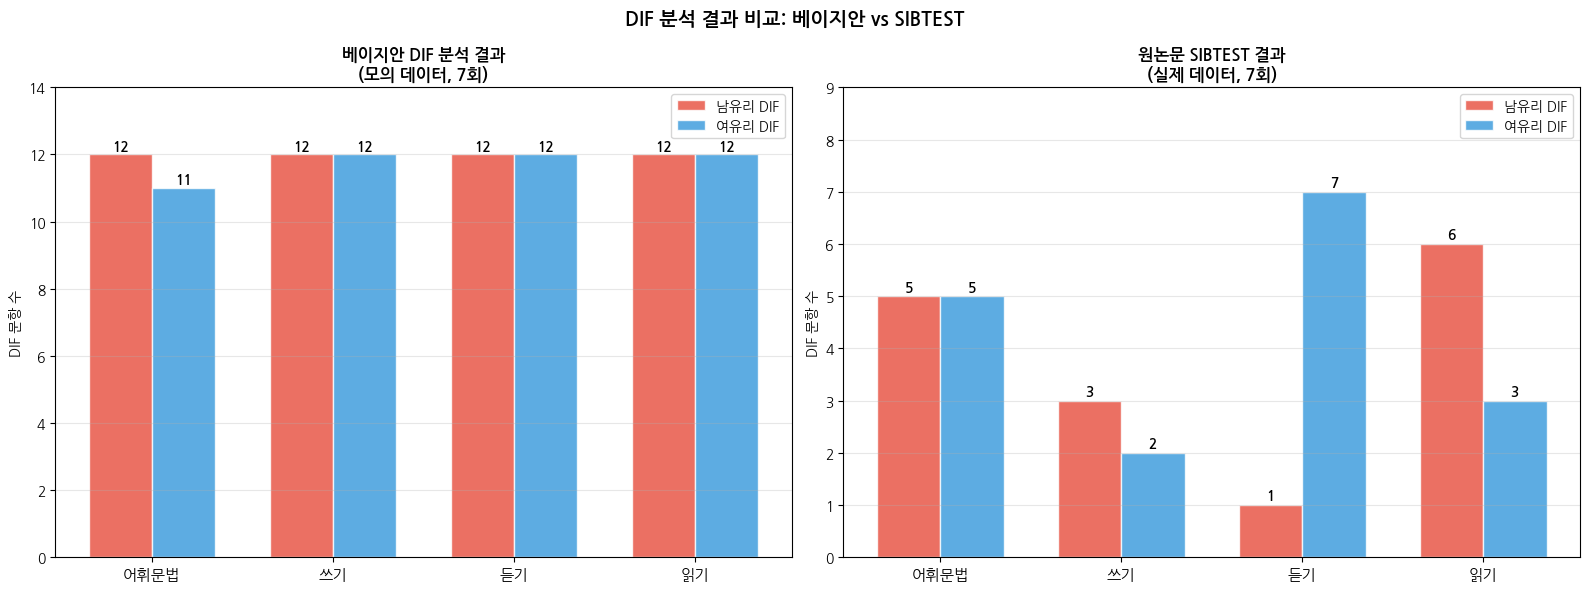


전체 결과 저장: results/all_dif_results.csv


In [ ]:
# ============================================================
# 셀 13: 전체 결과 요약 및 논문 표 7 비교
# ============================================================
print("=" * 70)
print("<전체 영역 베이지안 DIF 분석 요약>")
print("(논문 표 7 비교: 7회 모의 데이터 결과)")
print("=" * 70)

summary_data = []
for domain in DOMAINS:
    if domain not in all_dif_results or len(all_dif_results[domain]) == 0:
        summary_data.append({'영역': domain, '남유리 DIF': 0, '여유리 DIF': 0, '합계': 0})
        continue
    
    results    = all_dif_results[domain]
    male_fav   = sum(r['significant'] and r['direction'] == '남유리' for r in results)
    female_fav = sum(r['significant'] and r['direction'] == '여유리' for r in results)
    total_dif  = male_fav + female_fav
    
    summary_data.append({
        '영역':       domain,
        '남유리 DIF': male_fav,
        '여유리 DIF': female_fav,
        '합계':       total_dif
    })

summary_df = pd.DataFrame(summary_data)
print("\n[베이지안 분석 결과 (모의 데이터)]")
print(summary_df.to_string(index=False))

print("\n[원논문 결과 (7회)]")
paper_7th = {
    '영역':   ['어휘문법', '쓰기', '듣기', '읽기'],
    '남유리': [5, 3, 1, 6],
    '여유리': [5, 2, 7, 3]
}
print(pd.DataFrame(paper_7th).to_string(index=False))

# 종합 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax1 = axes[0]
x     = np.arange(len(DOMAINS))
width = 0.35

male_counts = [
    sum(r['significant'] and r['direction'] == '남유리'
        for r in all_dif_results.get(d, []))
    for d in DOMAINS
]
female_counts = [
    sum(r['significant'] and r['direction'] == '여유리'
        for r in all_dif_results.get(d, []))
    for d in DOMAINS
]

bars1 = ax1.bar(x - width / 2, male_counts,   width, label='남유리 DIF',
                color='#E74C3C', alpha=0.8, edgecolor='white')
bars2 = ax1.bar(x + width / 2, female_counts, width, label='여유리 DIF',
                color='#3498DB', alpha=0.8, edgecolor='white')

for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
             str(int(bar.get_height())), ha='center', va='bottom', fontweight='bold')
for bar in bars2:
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
             str(int(bar.get_height())), ha='center', va='bottom', fontweight='bold')

ax1.set_xticks(x)
ax1.set_xticklabels(DOMAINS, fontsize=11)
ax1.set_ylabel('DIF 문항 수')
ax1.set_title('베이지안 DIF 분석 결과\n(모의 데이터, 7회)', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3, axis='y')
max_val1 = max(male_counts + female_counts) if (male_counts + female_counts) else 1
ax1.set_ylim(0, max_val1 + 2)

ax2 = axes[1]
paper_male   = [5, 3, 1, 6]
paper_female = [5, 2, 7, 3]

bars3 = ax2.bar(x - width / 2, paper_male,   width, label='남유리 DIF',
                color='#E74C3C', alpha=0.8, edgecolor='white')
bars4 = ax2.bar(x + width / 2, paper_female, width, label='여유리 DIF',
                color='#3498DB', alpha=0.8, edgecolor='white')

for bar in bars3:
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
             str(int(bar.get_height())), ha='center', va='bottom', fontweight='bold')
for bar in bars4:
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
             str(int(bar.get_height())), ha='center', va='bottom', fontweight='bold')

ax2.set_xticks(x)
ax2.set_xticklabels(DOMAINS, fontsize=11)
ax2.set_ylabel('DIF 문항 수')
ax2.set_title('원논문 SIBTEST 결과\n(실제 데이터, 7회)', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3, axis='y')
ax2.set_ylim(0, max(paper_male + paper_female) + 2)

plt.suptitle('DIF 분석 결과 비교: 베이지안 vs SIBTEST',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/dif_summary_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# 전체 결과 저장
all_results_list = []
for domain, results in all_dif_results.items():
    all_results_list.extend(results)

if all_results_list:
    final_df = pd.DataFrame(all_results_list)
    final_df.to_csv('results/all_dif_results.csv', index=False, encoding='utf-8-sig')
    print("\n전체 결과 저장: results/all_dif_results.csv")

In [ ]:
# ============================================================
# 셀 14: 최종 정리 및 방법론 비교
# ============================================================
print("=" * 70)
print("베이지안 DIF 분석 완료 - 최종 정리")
print("=" * 70)

print("""
[분석 파이프라인 요약]

1단계: 데이터 생성
  - 논문 구조 (4영역 x 30문항, 남906/여1589명) 모의
  - 2PL IRT 모수로 응답 생성
  - CSV 저장 (data/kpik_simulation_round7.csv)

2단계: 일차원성 검증 (베이지안 2PL IRT)
  - 모든 문항의 변별도(a) 사후분포 확인
  - R-hat, ESS로 수렴 진단
  - Posterior Predictive Check
  - 판단: 모든 a의 95% HDI 하한 > 0 + 충분한 크기

3단계: DIF 분석 (베이지안 집단별 난이도 차이 모델)
  - delta_j = b_여_j - b_남_j 사후분포 추정
  - 95% HDI가 0을 포함하지 않으면 유의한 DIF
  - |delta|로 A/B/C 등급 분류 (Roussos & Stout 기준)
  - 방향: delta > 0 = 남유리, delta < 0 = 여유리

[SIBTEST vs 베이지안 핵심 차이]
항목           | SIBTEST(원논문)          | 베이지안(본 분석)
추정 패러다임  | 빈도주의                 | 베이지안
DIF 크기       | β 단일값                 | δ 사후분포 전체
불확실성 표현  | Standard Error           | 95% HDI
유의성 기준    | p < .05                  | 95% HDI에 0 미포함
사전 정보 활용 | 불가                     | 가능 (Prior)
소표본 처리    | 불안정                   | 사전분포로 안정화
""")

print("=" * 70)
print("분석 완료!")
print("=" * 70)

베이지안 DIF 분석 완료 - 최종 정리

[분석 파이프라인 요약]

1단계: 데이터 생성
  - 논문 구조 (4영역 x 30문항, 남906/여1589명) 모의
  - 2PL IRT 모수로 응답 생성
  - CSV 저장 (data/kpik_simulation_round7.csv)

2단계: 일차원성 검증 (베이지안 2PL IRT)
  - 모든 문항의 변별도(a) 사후분포 확인
  - R-hat, ESS로 수렴 진단
  - Posterior Predictive Check
  - 판단: 모든 a의 95% HDI 하한 > 0 + 충분한 크기

3단계: DIF 분석 (베이지안 집단별 난이도 차이 모델)
  - delta_j = b_여_j - b_남_j 사후분포 추정
  - 95% HDI가 0을 포함하지 않으면 유의한 DIF
  - |delta|로 A/B/C 등급 분류 (Roussos & Stout 기준)
  - 방향: delta > 0 = 남유리, delta < 0 = 여유리

[SIBTEST vs 베이지안 핵심 차이]
항목           | SIBTEST(원논문)          | 베이지안(본 분석)
추정 패러다임  | 빈도주의                 | 베이지안
DIF 크기       | β 단일값                 | δ 사후분포 전체
불확실성 표현  | Standard Error           | 95% HDI
유의성 기준    | p < .05                  | 95% HDI에 0 미포함
사전 정보 활용 | 불가                     | 가능 (Prior)
소표본 처리    | 불안정                   | 사전분포로 안정화

분석 완료!


| 원논문 개념 | 베이지안 대응 | Stan 코드 |
|---|---|---|
| SIBTEST β | `delta[j]` 사후 평균 | `vector[J] delta` |
| Standard Error | `delta[j]` 사후 SD | `az.summary()` |
| p < .05 | 95% HDI ∌ 0 | `az.hdi()` |
| A/B/C 등급 | `|E[delta\|Y]|` 기준 | `generated quantities` |